In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd
from collections import defaultdict

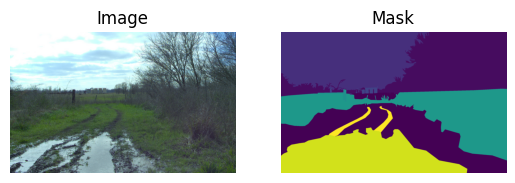

In [3]:
img_path = "../../data/RELLIS-3D/images/00000/pylon_camera_node/frame000000-1581624652_750.jpg"
mask_path = "../../data/RELLIS-3D/annotations/00000/pylon_camera_node_label_id/frame000000-1581624652_750.png"

img = Image.open(img_path)
mask = Image.open(mask_path)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()

In [7]:
from pathlib import Path
import pandas as pd

frames_root = Path("../../data/RELLIS-3D/images")
masks_root = Path("../../data/RELLIS-3D/annotations")

records = []

for sequence_dir in frames_root.iterdir():

    if not sequence_dir.is_dir():
        continue

    sequence_name = sequence_dir.name

    image_dir = sequence_dir / "pylon_camera_node"
    mask_dir = masks_root / sequence_name / "pylon_camera_node_label_id"

    if not image_dir.exists() or not mask_dir.exists():
        continue

    # Create lookup table for images
    image_lookup = {
        img.stem: img
        for img in image_dir.glob("*.jpg")
    }

    # Iterate through masks
    for mask_path in mask_dir.glob("*.png"):

        if mask_path.stem not in image_lookup:
            continue

        img_path = image_lookup[mask_path.stem]

        records.append({
            "sequence": sequence_name,
            "image_path": str(img_path),
            "mask_path": str(mask_path)
        })

df_2 = pd.DataFrame(records)

df_2.head()

,sequence,image_path,mask_path
0,00000,..\..\data\RELLIS-3D\images\00000\pylon_camera...,..\..\data\RELLIS-3D\annotations\00000\pylon_c...
1,00000,..\..\data\RELLIS-3D\images\00000\pylon_camera...,..\..\data\RELLIS-3D\annotations\00000\pylon_c...
2,00000,..\..\data\RELLIS-3D\images\00000\pylon_camera...,..\..\data\RELLIS-3D\annotations\00000\pylon_c...
3,00000,..\..\data\RELLIS-3D\images\00000\pylon_camera...,..\..\data\RELLIS-3D\annotations\00000\pylon_c...
4,00000,..\..\data\RELLIS-3D\images\00000\pylon_camera...,..\..\data\RELLIS-3D\annotations\00000\pylon_c...


In [8]:
print(f"Number of images in data frame: {len(df_2)}")

Number of images in data frame: 6234


In [9]:
mask = df_2["mask_path"][1500]
print(f"Path: {mask}")
mask_img = Image.open(mask)
mask_array = np.array(mask_img)

shape = mask_array.shape
print(f"Shape: {shape}")

mask_reshape = mask_array.reshape(-1)
print(f"Reshape: {mask_reshape.shape}")

from collections import defaultdict

unique_colors = defaultdict()

for color in mask_reshape:
    # color = color.tolist()
    if color not in unique_colors:
        unique_colors[color] = 0
    unique_colors[color] += 1

print(f"Number of unique colors: {len(unique_colors)}")
print("\n")

Path: ..\..\data\RELLIS-3D\annotations\00001\pylon_camera_node_label_id\frame000600-1581623850_350.png
Shape: (1200, 1920)
Reshape: (2304000,)
Number of unique colors: 6




In [10]:
id_to_class_name = {
    0: "void",
    1: "dirt",
    3: "grass",
    4: "tree",
    5: "pole",
    6: "water",
    7: "sky",
    8: "vehicle",
    9: "object",
    10: "asphalt",
    12: "building",
    15: "log",
    17: "person",
    18: "fence",
    19: "bush",
    23: "concrete",
    27: "barrier",
    31: "puddle",
    33: "mud",
    34: "rubble",
}

Class 'sky' takes up 23.47% of the total pixels on the image
Class 'tree' takes up 25.26% of the total pixels on the image
Class 'bush' takes up 12.41% of the total pixels on the image
Class 'grass' takes up 25.78% of the total pixels on the image
Class 'mud' takes up 4.1% of the total pixels on the image
Class 'puddle' takes up 8.97% of the total pixels on the image
The percentages add up to (after rounding): 99.99%


<function matplotlib.pyplot.show(close=None, block=None)>

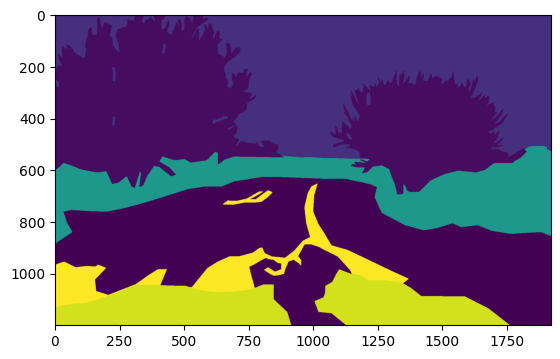

In [11]:
sanity_check = 0
for color in unique_colors:
    percentage = round(unique_colors[color] / mask_reshape.shape[0] * 100, 2)
    sanity_check += percentage
    print(f"Class \'{id_to_class_name[color]}\' takes up {percentage}% of the total pixels on the image")

print(f"The percentages add up to (after rounding): {sanity_check}%")

plt.imshow(mask_img)
plt.show

In [12]:
rellis_counts = defaultdict(int)
# sample_df = df_2.sample(n=623, random_state=42)
sample_df = df_2

for path in sample_df["mask_path"]:
    img = Image.open(path)
    mask_array = np.array(img)

    mask_reshape = mask_array.reshape(-1)
    ids, counts = np.unique(mask_reshape, return_counts=True , axis=0)

    for i in range(len(ids)):
        # color = tuple(int(x) for x in colors[i])
        # dataset_color_counts[color] += counts[i]
        id = ids[i]
        rellis_counts[id] += counts[i]

print(f"Number of unique colors: {len(rellis_counts)}")
print("\n")
print(rellis_counts)

total = sum(rellis_counts.values())

print("\n=== CLASS DISTRIBUTION (%) ===")

found_ids = []
found_per = []
found_counts = []

for id, count in sorted(rellis_counts.items(), key=lambda x: x[1], reverse=True):
    pct = (count / total) * 100
    print(f"{id_to_class_name[id]}: {pct:.2f}% ({count})")
    found_ids.append(id_to_class_name[id])
    found_per.append(round(pct, 2))
    found_counts.append(count)

print(found_ids)
print(found_per)
print(found_counts)

KeyboardInterrupt: 

In [ ]:
plt.barh(found_ids[::-1], found_per[::-1])

plt.xlabel("Disctribution percentage per pixel (%)")
plt.ylabel("Classes")
plt.title("RELLIS-3D Class Distribution")

plt.tight_layout()
plt.show()

plt.barh(found_ids[::-1], found_counts[::-1])

plt.xlabel("Disctribution per pixel")
plt.ylabel("Classes")
plt.title("RELLIS-3D Class Distribution")

plt.tight_layout()
plt.show()